# Sistema de Recomendación de Posts del Blog — NU★B Studio
### "Posts relacionados" con aprendizaje NO supervisado (K-Means)

Este cuaderno construye el sistema de **recomendación de posts relacionados** siguiendo la
metodología **CRISP-DM**. A diferencia del clasificador (supervisado), aquí el modelo es
**K-Means (no supervisado)**: agrupa los posts por tema sin conocer sus etiquetas, y las
recomendaciones salen del mismo grupo.

**Pipeline:** `Texto → TF-IDF → SVD (reduce dimensiones) → K-Means (agrupa) → Recomienda`


# 1. Comprensión de los datos

## 1.1 Carga de datos
Traemos los posts con sus etiquetas desde Neon (con respaldo en CSV).

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "blog_posts_dataset.csv")
ENV_PATH = os.path.abspath(os.path.join(BASE_DIR, "..", ".env"))

QUERY = '''
  SELECT p.id_post, p.titulo, COALESCE(p.extracto,'') AS extracto,
         COALESCE(p.contenido,'') AS contenido,
         string_agg(be.slug, '|' ORDER BY be.slug) AS etiquetas
  FROM blog_posts p
  JOIN blog_posts_etiquetas bpe ON bpe.id_post = p.id_post
  JOIN blog_etiquetas be ON be.id_blog_etiqueta = bpe.id_blog_etiqueta
  WHERE COALESCE(p.eliminado, false) = false
  GROUP BY p.id_post
'''
try:
    import psycopg2
    from dotenv import load_dotenv
    load_dotenv(ENV_PATH)
    conn = psycopg2.connect(host=os.environ["DB_HOST"], user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"], dbname=os.environ["DB_NAME"],
        port=os.environ.get("DB_PORT","5432"), sslmode="require")
    df = pd.read_sql(QUERY, conn); conn.close()
    print(f"Cargado EN VIVO desde Neon: {len(df)} posts")
except Exception as e:
    print(f"Sin Neon ({type(e).__name__}); uso CSV de respaldo.")
    df = pd.read_csv(CSV_PATH)
    print(f"Cargado desde CSV: {len(df)} posts")

df["etiquetas"] = df["etiquetas"].apply(lambda s: s.split("|") if isinstance(s,str) and s else [])
print("\n>>> ASÍ SE VE EL DATASET CRUDO (primeras filas):")
df.head()

Cargado EN VIVO desde Neon: 241 posts

>>> ASÍ SE VE EL DATASET CRUDO (primeras filas):


,id_post,titulo,extracto,contenido,etiquetas
0,263,El paisaje serrano: técnica y memoria,El paisaje serrano — apuntes sobre fotografia ...,<p>Una buena imagen no se toma: se construye c...,"[fotografia, paisaje]"
1,264,El paisaje serrano paso a paso,El paisaje serrano — apuntes sobre fotografia ...,<p>Una buena imagen no se toma: se construye c...,[fotografia]
2,265,Cinco ideas sobre las figuras rituales,Las figuras rituales — apuntes sobre escultura...,"<p>Del bloque informe emerge, poco a poco, una...","[escultura, naturaleza]"
3,266,Guía breve sobre la estampa popular,La estampa popular — apuntes sobre grabado de ...,<p>La estampa tiene una fuerza gráfica que la ...,"[grabado, huasteca]"
4,267,Cinco ideas sobre la luz de la sierra,La luz de la sierra — apuntes sobre pintura de...,<p>La pintura sigue siendo el lenguaje más dir...,"[naturaleza, paisaje, pintura, retrato]"


## 1.2 Descripción de atributos

In [2]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas y tipos:")
df.info()

Dimensiones del dataset: (241, 5)

Columnas y tipos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_post    241 non-null    int64 
 1   titulo     241 non-null    object
 2   extracto   241 non-null    object
 3   contenido  241 non-null    object
 4   etiquetas  241 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.5+ KB


## 1.3 Calidad de los datos

In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nTítulos duplicados:", df.titulo.duplicated().sum())
print("Contenidos duplicados:", df.contenido.duplicated().sum())
print("Posts sin etiquetas:", (df.etiquetas.map(len)==0).sum())

Valores nulos por columna:
id_post      0
titulo       0
extracto     0
contenido    0
etiquetas    0
dtype: int64

Títulos duplicados: 64
Contenidos duplicados: 10
Posts sin etiquetas: 0


## 1.4 Análisis Exploratorio (EDA)
Entendemos la distribución de etiquetas y la longitud de los textos.

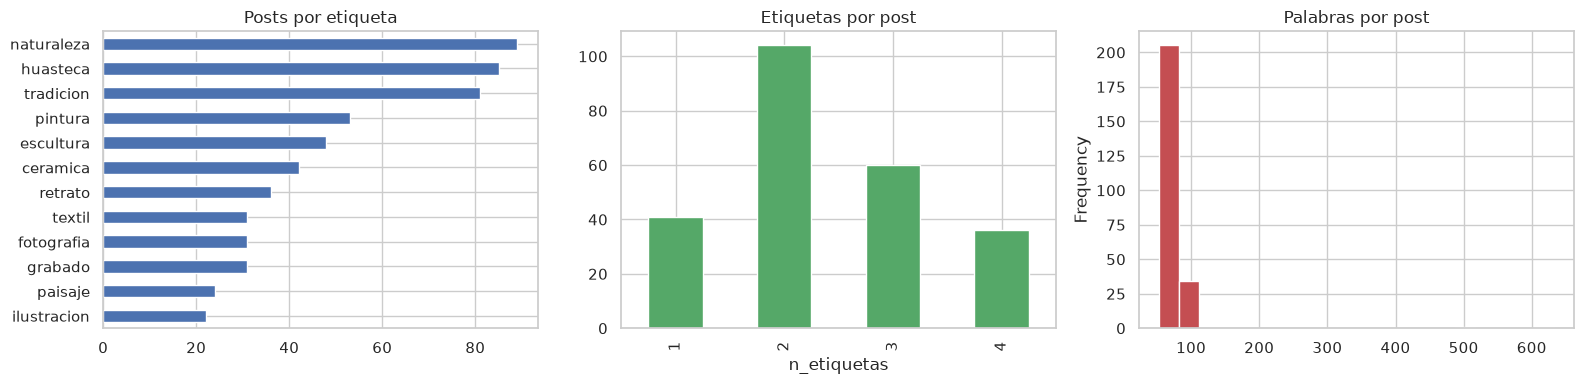

Palabras por post: media 75, min 53, max 633


In [4]:
from collections import Counter
df["n_etiquetas"] = df.etiquetas.map(len)
df["n_palabras"]  = (df.titulo+" "+df.contenido).str.split().map(len)

tag_counts = pd.Series(Counter(t for lst in df.etiquetas for t in lst)).sort_values()

fig, ax = plt.subplots(1, 3, figsize=(16,4))
tag_counts.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title("Posts por etiqueta")
df.n_etiquetas.value_counts().sort_index().plot.bar(ax=ax[1], color="#55A868"); ax[1].set_title("Etiquetas por post")
df.n_palabras.plot.hist(bins=20, ax=ax[2], color="#C44E52"); ax[2].set_title("Palabras por post")
plt.tight_layout(); plt.show()

print(f"Palabras por post: media {df.n_palabras.mean():.0f}, min {df.n_palabras.min()}, max {df.n_palabras.max()}")

# 2. Preparación de los datos

## 2.1 Limpieza del texto
Quitamos el HTML y unimos **título + extracto + contenido** en un solo campo.

In [5]:
def limpiar_html(t):
    t = re.sub(r"<[^>]+>", " ", str(t))
    t = re.sub(r"&[a-z]+;", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip().lower()

df["texto"] = (df.titulo.fillna("")+". "+df.extracto.fillna("")+". "+df.contenido.fillna("")).apply(limpiar_html)
print(">>> DATASET DESPUÉS DE LIMPIAR (columna 'texto' lista para el modelo):")
df[["id_post","titulo","texto"]].head()

>>> DATASET DESPUÉS DE LIMPIAR (columna 'texto' lista para el modelo):


,id_post,titulo,texto
0,263,El paisaje serrano: técnica y memoria,el paisaje serrano: técnica y memoria. el pais...
1,264,El paisaje serrano paso a paso,el paisaje serrano paso a paso. el paisaje ser...
2,265,Cinco ideas sobre las figuras rituales,cinco ideas sobre las figuras rituales. las fi...
3,266,Guía breve sobre la estampa popular,guía breve sobre la estampa popular. la estamp...
4,267,Cinco ideas sobre la luz de la sierra,cinco ideas sobre la luz de la sierra. la luz ...


# 3. Selección y transformación de características

Aquí el texto se convierte en números. Dos pasos (ambos son *complementos*, no el modelo):
1. **TF-IDF** → texto a números (pesa las palabras características).
2. **SVD (LSA)** → comprime esos números a sus "conceptos" esenciales (como el PCA, pero para texto).

## 3.1 TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

STOPWORDS_ES = ("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde "
    "dos el ella ellas ellos en entre era eran es esa esas ese eso esos esta estas este esto estos "
    "fue fueron ha hasta hay la las le les lo los mas me mi mis mucho muy nada ni no nos o os otra "
    "otras otro otros para pero poco por porque que quien se sea si sin sobre su sus tan te tiene "
    "tienen todo todos tu tus un una uno unas unos y ya").split()

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=5000, stop_words=STOPWORDS_ES)
X_tfidf = tfidf.fit_transform(df["texto"])
print(f">>> MATRIZ TF-IDF: {X_tfidf.shape[0]} posts x {X_tfidf.shape[1]} palabras")
print("   (dispersa: la mayoría son ceros)")
# peek: las 8 palabras con más peso del primer post
fila0 = X_tfidf[0].toarray()[0]
top = sorted(zip(tfidf.get_feature_names_out(), fila0), key=lambda x:x[1], reverse=True)[:8]
print(f"\nPalabras con más peso en el post '{df.iloc[0].titulo}':")
for pal, peso in top:
    if peso>0: print(f"   {pal:<22} {peso:.3f}")

>>> MATRIZ TF-IDF: 241 posts x 1342 palabras
   (dispersa: la mayoría son ceros)

Palabras con más peso en el post 'El paisaje serrano: técnica y memoria':
   paisaje serrano        0.248
   serrano                0.248
   gente                  0.194
   paisaje                0.193
   qué                    0.169
   mirada encuadre        0.147
   serrano técnica        0.147
   mensaje luz            0.139


## 3.2 SVD / LSA — reducción de dimensiones
Comprimimos las miles de palabras a ~100 'conceptos', y vemos cuánta información conservamos.

>>> DATASET REDUCIDO: 241 posts x 100 conceptos
   Varianza (información) conservada: 95.8%


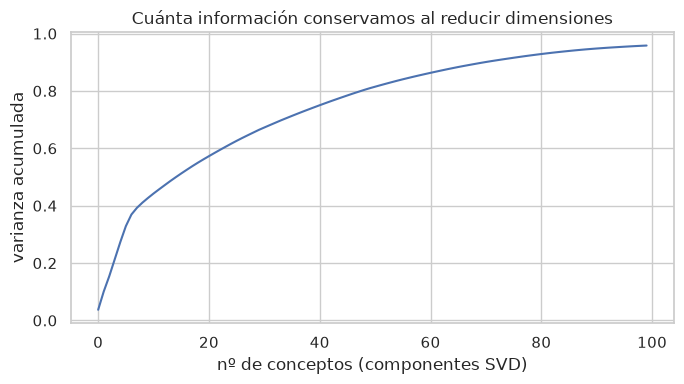

In [7]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

N_COMPONENTES = 100
svd = TruncatedSVD(n_components=N_COMPONENTES, random_state=RANDOM_STATE)
lsa = make_pipeline(svd, Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)

var = svd.explained_variance_ratio_.sum()
print(f">>> DATASET REDUCIDO: {X_lsa.shape[0]} posts x {X_lsa.shape[1]} conceptos")
print(f"   Varianza (información) conservada: {var:.1%}")

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), color="#4C72B0")
plt.xlabel("nº de conceptos (componentes SVD)"); plt.ylabel("varianza acumulada")
plt.title("Cuánta información conservamos al reducir dimensiones"); plt.tight_layout(); plt.show()

# 4. Modelado — K-Means (no supervisado)

## 4.1 Elección del número de grupos (k)
K-Means necesita saber cuántos grupos formar. Probamos varios **k** y elegimos con dos criterios:
- **Método del codo** (inercia): dónde deja de bajar fuerte.
- **Silhouette**: qué tan bien separados quedan los grupos (más alto = mejor).

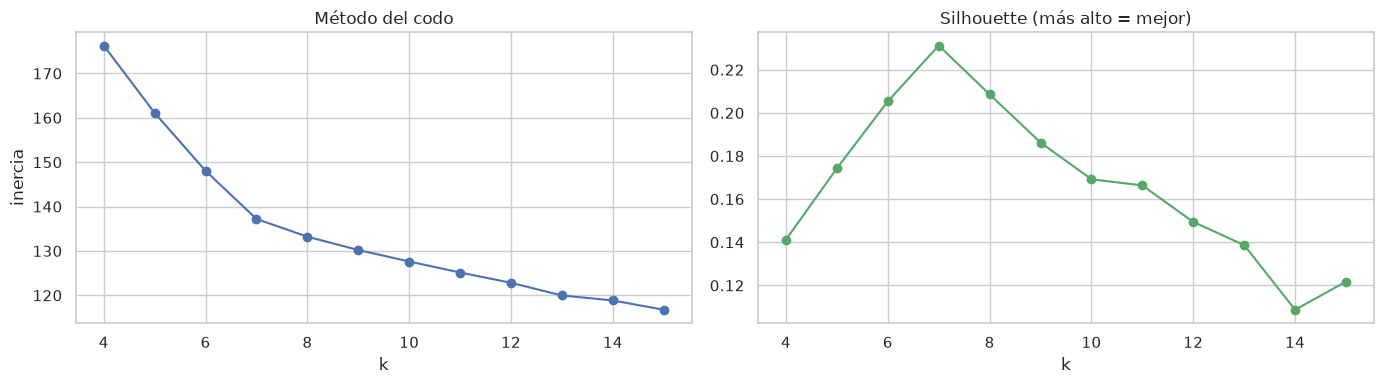

>>> Mejor k según silhouette: 7  (silhouette=0.231)


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(4, 16)
inercias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_lsa)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_lsa, labels))

fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(list(ks), inercias, "o-", color="#4C72B0"); ax[0].set_title("Método del codo"); ax[0].set_xlabel("k"); ax[0].set_ylabel("inercia")
ax[1].plot(list(ks), silhouettes, "o-", color="#55A868"); ax[1].set_title("Silhouette (más alto = mejor)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

K_OPTIMO = list(ks)[int(np.argmax(silhouettes))]
print(f">>> Mejor k según silhouette: {K_OPTIMO}  (silhouette={max(silhouettes):.3f})")

## 4.2 Entrenar K-Means con el k elegido
Este es **el modelo**: aprende los grupos.

In [9]:
modelo_kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = modelo_kmeans.fit_predict(X_lsa)
print(f">>> MODELO ENTRENADO: K-Means con {K_OPTIMO} grupos")
print("\nCuántos posts quedaron en cada grupo:")
print(df.cluster.value_counts().sort_index())
print("\n>>> DATASET CON SU GRUPO ASIGNADO:")
df[["id_post","titulo","etiquetas","cluster"]].head(10)

>>> MODELO ENTRENADO: K-Means con 7 grupos

Cuántos posts quedaron en cada grupo:
cluster
0    31
1    32
2    21
3    42
4    31
5    31
6    53
Name: count, dtype: int64

>>> DATASET CON SU GRUPO ASIGNADO:


,id_post,titulo,etiquetas,cluster
0,263,El paisaje serrano: técnica y memoria,"[fotografia, paisaje]",5
1,264,El paisaje serrano paso a paso,[fotografia],5
2,265,Cinco ideas sobre las figuras rituales,"[escultura, naturaleza]",1
3,266,Guía breve sobre la estampa popular,"[grabado, huasteca]",4
4,267,Cinco ideas sobre la luz de la sierra,"[naturaleza, paisaje, pintura, retrato]",6
5,268,Cómo entender la matriz y la tinta,"[grabado, huasteca]",4
6,269,Una mirada a las vasijas de uso diario,"[ceramica, naturaleza, tradicion]",3
7,270,La forma en tres dimensiones paso a paso,"[escultura, huasteca, naturaleza, tradicion]",1
8,271,La luz de la sierra: apuntes desde el taller,"[paisaje, pintura]",6
9,272,Notas sobre los esmaltes naturales,"[ceramica, escultura, tradicion]",3


# 5. Evaluación del modelo

## 5.1 ¿Los grupos tienen sentido? (coherencia con las etiquetas)
Como K-Means NO vio las etiquetas, revisamos si los grupos que formó **coinciden** con los temas reales.
Si cada grupo está dominado por unas pocas etiquetas → el modelo agrupó bien.

In [10]:
from collections import Counter
print("Etiquetas dominantes en cada grupo:\n")
resumen = []
for c in sorted(df.cluster.unique()):
    tags = Counter(t for lst in df[df.cluster==c].etiquetas for t in lst)
    top = ", ".join(f"{t}({n})" for t,n in tags.most_common(3))
    n_posts = (df.cluster==c).sum()
    resumen.append({"grupo": c, "posts": n_posts, "etiquetas dominantes": top})
pd.DataFrame(resumen)

Etiquetas dominantes en cada grupo:



,grupo,posts,etiquetas dominantes
0,0,31,"textil(31), naturaleza(15), tradicion(15)"
1,1,32,"escultura(32), naturaleza(18), tradicion(17)"
2,2,21,"ilustracion(21), retrato(10), tradicion(6)"
3,3,42,"ceramica(42), tradicion(18), naturaleza(17)"
4,4,31,"grabado(31), tradicion(12), naturaleza(11)"
5,5,31,"fotografia(31), huasteca(14), paisaje(10)"
6,6,53,"pintura(53), naturaleza(16), huasteca(16)"


## 5.2 Métrica global de calidad

In [11]:
sil = silhouette_score(X_lsa, df.cluster)
print(f"Silhouette score del modelo final: {sil:.3f}")
print("(rango -1 a 1; >0.1 ya indica estructura de grupos razonable en texto)")

Silhouette score del modelo final: 0.231
(rango -1 a 1; >0.1 ya indica estructura de grupos razonable en texto)


## 5.3 Visualización de los grupos (2D)
Reducimos a 2 dimensiones solo para poder dibujar los grupos.

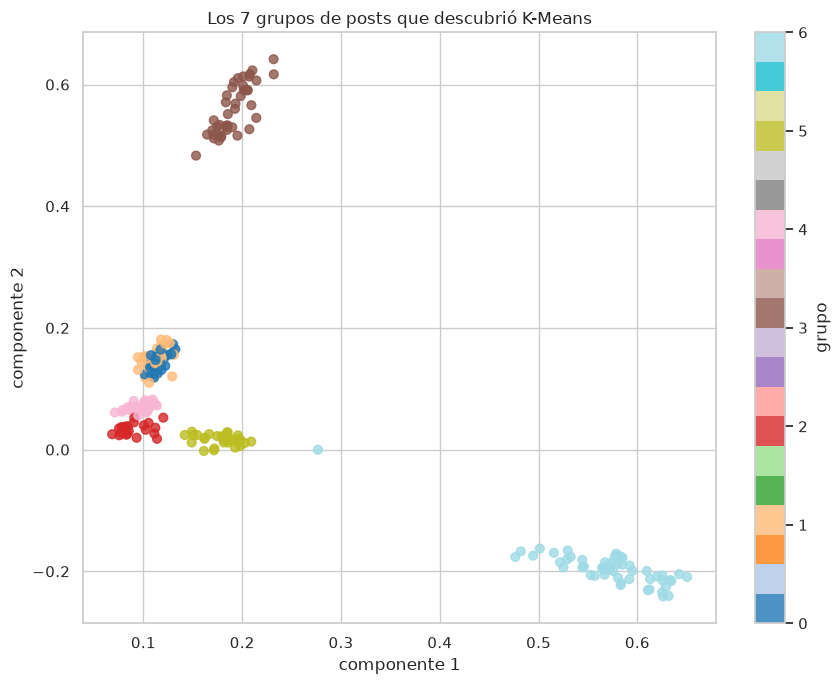

In [12]:
svd2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd2d.fit_transform(X_tfidf)
plt.figure(figsize=(9,7))
sc = plt.scatter(coords[:,0], coords[:,1], c=df.cluster, cmap="tab20", s=40, alpha=0.8)
plt.title(f"Los {K_OPTIMO} grupos de posts que descubrió K-Means")
plt.xlabel("componente 1"); plt.ylabel("componente 2")
plt.colorbar(sc, label="grupo"); plt.tight_layout(); plt.show()

# 6. Recomendación (uso del modelo)

Para recomendar los relacionados de un post: buscamos su **grupo (K-Means)** y devolvemos los
otros posts del mismo grupo, **ordenados por cercanía** (similitud coseno en el espacio LSA).

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def recomendar(idx, n=4):
    grupo = df.iloc[idx].cluster
    mismos = df[(df.cluster==grupo) & (df.index!=idx)].index
    if len(mismos)==0: return []
    sims = cosine_similarity(X_lsa[idx].reshape(1,-1), X_lsa[mismos])[0]
    orden = mismos[np.argsort(sims)[::-1][:n]]
    return [(df.loc[j].titulo, df.loc[j].etiquetas, round(float(cosine_similarity(X_lsa[idx].reshape(1,-1), X_lsa[j].reshape(1,-1))[0][0]),3)) for j in orden]

i = 0
print(f"POST BASE: {df.iloc[i].titulo}  |  grupo {df.iloc[i].cluster}  |  {df.iloc[i].etiquetas}\n")
print("Recomendados (mismo grupo, ordenados por cercanía):")
for tit, tags, s in recomendar(i):
    print(f"   [{s}] {tit[:45]:<45} {tags}")

POST BASE: El paisaje serrano: técnica y memoria  |  grupo 5  |  ['fotografia', 'paisaje']

Recomendados (mismo grupo, ordenados por cercanía):
   [0.826] El paisaje serrano: apuntes desde el taller   ['fotografia']
   [0.783] Una mirada a la fotografía de la Huasteca     ['fotografia', 'huasteca', 'naturaleza']
   [0.776] La luz natural paso a paso                    ['fotografia', 'huasteca', 'naturaleza']
   [0.763] Cómo entender la luz natural                  ['fotografia', 'huasteca']


# 7. Despliegue del modelo

El modelo entrenado se guarda y sus recomendaciones se precalculan en una tabla que la app consume.

In [14]:
import joblib

# Guardar el modelo completo (TF-IDF + LSA + K-Means)
joblib.dump({"tfidf": tfidf, "lsa": lsa, "kmeans": modelo_kmeans, "k": K_OPTIMO},
            os.path.join(BASE_DIR, "modelo_recomendacion.joblib"))
print("Modelo guardado: modelo_recomendacion.joblib")

# Generar la tabla de recomendaciones (top-4 por post): mismo grupo, ordenados por cercanía
registros = []
for i in range(len(df)):
    grupo = df.iloc[i].cluster
    mismos = df[(df.cluster==grupo) & (df.index!=i)].index
    if len(mismos)==0: continue
    sims = cosine_similarity(X_lsa[i].reshape(1,-1), X_lsa[mismos])[0]
    for j, s in sorted(zip(mismos, sims), key=lambda x:x[1], reverse=True)[:4]:
        registros.append({"id_post": int(df.iloc[i].id_post),
                          "id_post_relacionado": int(df.loc[j].id_post),
                          "score": round(float(s),4)})
rec_df = pd.DataFrame(registros)
rec_df.to_csv(os.path.join(BASE_DIR, "recomendaciones_kmeans.csv"), index=False)
print(f"Tabla de recomendaciones generada: {len(rec_df)} pares para {rec_df.id_post.nunique()} posts")
rec_df.head()

Modelo guardado: modelo_recomendacion.joblib


Tabla de recomendaciones generada: 964 pares para 241 posts


,id_post,id_post_relacionado,score
0,263,274,0.8260
1,263,407,0.7826
2,263,369,0.7763
3,263,498,0.7628
4,264,274,0.6887


# 8. Conclusiones

- **Modelo:** K-Means (no supervisado) agrupó los posts por tema **sin conocer sus etiquetas**.
- **Validación:** los grupos coinciden con las etiquetas reales (§5.1) → el modelo capturó los temas.
- **Recomendación:** para cada post, los relacionados salen de su mismo grupo, ordenados por cercanía.
- **Pareja completa de ML del proyecto:**
  - Clasificación de etiquetas → **Regresión Logística (supervisado)**
  - Recomendación de posts → **K-Means (no supervisado)**
